# Chapter 4 — Conditioning and stability

**Numerical Linear Algebra: Theory, Algorithms, and Computation**

**Abdallah Alsammani, Ph.D.**  
Department of Mathematical Sciences & Data Science  
Delaware State University

Lecture notes: <https://aalsammani.github.io/numerical-linear-algebra/>  
Notes for this chapter: <https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html>  
Repository: <https://github.com/aalsammani/Numerical-Linear-Algebra-Notebooks>

This notebook is the computational laboratory of the chapter; the theory,
proofs and exercises are in the lecture notes, to which the links below
point. References such as Trefethen and Bau (1997) are listed in the
[bibliography of the notes](https://aalsammani.github.io/numerical-linear-algebra/back/bibliography.html). Version
1.0, September 2026.

---

This notebook accompanies [Chapter 4](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04) of the notes. Each
experiment checks a statement of the chapter numerically, and the checks use
tolerances derived from error bounds rather than tolerances chosen by trial
and error.

**Learning objectives.** After working through this lab you should be able to

1. estimate condition numbers of simple problems numerically and compare them
   with the formulas of the chapter;
2. build matrices with prescribed singular values and use them to test the
   perturbation theorem for $Ax = b$, including its sharpness;
3. compute forward errors, Rigal--Gaches and Oettli--Prager backward errors,
   and relative residuals, and explain how they differ;
4. compare Skeel's condition number with $\kappa_\infty(A)$ for a badly
   row-scaled matrix;
5. recognize unstable algorithms for well-conditioned problems and replace
   them by stable ones;
6. separate, for the Hilbert matrix, the error caused by rounding the data
   from the error caused by the solver.

Run the cells in order from a fresh kernel. Some checks use exact rational
arithmetic from Python's `fractions` module, which is slow but free of
rounding errors; it is used only for small problems.

In [1]:
import math
from fractions import Fraction

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as sla

rng = np.random.default_rng(20260404)
u = np.finfo(float).eps / 2          # unit roundoff of IEEE double precision, 2**-53
plt.rcParams.update({"figure.figsize": (6.4, 4.0), "axes.grid": True, "grid.alpha": 0.3})


def gamma(k):
    """Higham's constant gamma_k = k u / (1 - k u)."""
    return k * u / (1 - k * u)


def fractions_of(v):
    """Exact rational copies of the entries of a float array (every float is a rational number)."""
    return [Fraction(float(t)) for t in np.ravel(v)]


print(f"NumPy {np.__version__}; unit roundoff u = {u:.3e}")

NumPy 2.5.3; unit roundoff u = 1.110e-16


## 1. Condition numbers of scalar problems

For a differentiable function of one variable the relative condition number
is $\kappa(x) = |x f'(x)/f(x)|$ ([Theorem 4.1](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-thm-jacobian)). We estimate it
by perturbing $x$ to $x(1+t)$ for a small $t$ and measuring the relative
change of $f$. The estimate has two errors: a truncation error of order $t$
from the nonlinearity of $f$, and a rounding error of order $u\kappa/(t\kappa)
= u/t$ from evaluating $f$ in floating point. With $t = 10^{-7}$ both are at
most about $10^{-6}$ relative (the truncation error is largest for $e^x$ at
$x = 20$, about $xt/2 = 10^{-6}$), so we test agreement to $10^{-5}$.

In [2]:
def cond_estimate(f, x, t=1e-7):
    """Relative change of f divided by the relative change t of x."""
    return abs((f(x * (1 + t)) - f(x)) / f(x)) / t


cases = [
    ("sqrt(x), x = 7", np.sqrt, 7.0, 0.5),
    ("exp(x), x = 20", np.exp, 20.0, 20.0),
    ("log(x), x = 1 + 1e-6", np.log, 1 + 1e-6, 1 / abs(np.log(1 + 1e-6))),
    ("x - 1, x = 1.001", lambda z: z - 1.0, 1.001, 1.001 / 0.001),
]
print(f"{'problem':24s} {'estimate':>12s} {'formula':>12s}")
for name, f, x, kappa in cases:
    est = cond_estimate(f, x)
    print(f"{name:24s} {est:12.5g} {kappa:12.5g}")
    assert abs(est / kappa - 1) < 1e-5

problem                      estimate      formula
sqrt(x), x = 7                    0.5          0.5
exp(x), x = 20                     20           20
log(x), x = 1 + 1e-6            1e+06        1e+06
x - 1, x = 1.001                 1001         1001


Square roots halve relative errors, the exponential multiplies them by $|x|$,
and the logarithm near $1$ and the subtraction $x - 1$ near $x = 1$ magnify
them enormously. These last two are the same phenomenon, cancellation:
$\log x\approx x - 1$ near $x = 1$.

### Evaluating a polynomial near a root

[Example 4.2](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-exa-polynomial) evaluates $(x-2)^9$ from its expanded
coefficients by Horner's rule. The computed value satisfies
$|\hat p(x) - p(x)|\le\gamma_{18}\sum_k|a_k||x|^k$, and the condition number
with respect to the coefficients is $((x+2)/|x-2|)^9$ for $x\ge0$.

coefficients: [    1   -18   144  -672  2016 -4032  5376 -4608  2304  -512]
max |p(x)| on the grid       = 1.95e-12
max observed error           = 1.33e-11
max of the bound gamma_18 sum |a_k||x|^k = 5.86e-10
fraction of grid points with the wrong sign: 0.50


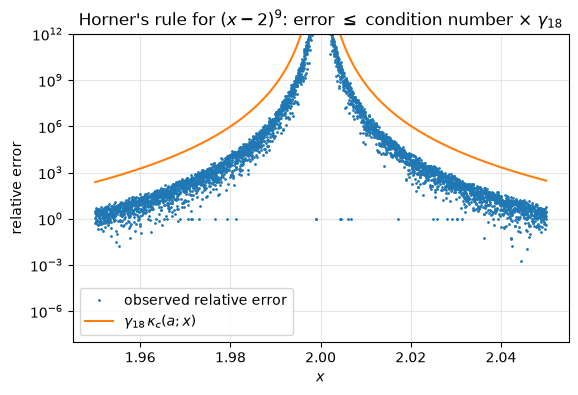

In [3]:
coeffs = np.array([math.comb(9, k) * (-2.0) ** k for k in range(10)])  # descending powers, exact integers
print("coefficients:", coeffs.astype(int))


def horner(c, x):
    p = np.zeros_like(x)
    for a in c:
        p = p * x + a
    return p


x = np.linspace(1.95, 2.05, 4001)
p_hat = horner(coeffs, x)
p_true = (x - 2.0) ** 9                  # x - 2 is exact here (Sterbenz), so this is accurate to ~9u relative
err = np.abs(p_hat - p_true)
bound = gamma(18) * horner(np.abs(coeffs), np.abs(x))
print(f"max |p(x)| on the grid       = {np.abs(p_true).max():.2e}")
print(f"max observed error           = {err.max():.2e}")
print(f"max of the bound gamma_18 sum |a_k||x|^k = {bound.max():.2e}")
print(f"fraction of grid points with the wrong sign: {np.mean(np.sign(p_hat) != np.sign(p_true)):.2f}")
# the reference itself has relative error <= 9u, negligible next to the bound
assert np.all(err <= bound + 10 * u * np.abs(p_true))

fig, ax = plt.subplots()
keep = x != 2.0                          # the grid contains the root itself, where p = 0
kappa_c = ((x[keep] + 2) / np.abs(x[keep] - 2)) ** 9
ax.semilogy(x[keep], np.maximum(err[keep] / np.abs(p_true[keep]), 1e-17), ".", ms=2,
            label="observed relative error")
ax.semilogy(x[keep], gamma(18) * kappa_c, "-", lw=1.5, label=r"$\gamma_{18}\,\kappa_c(a;x)$")
ax.set_ylim(1e-8, 1e12)
ax.set_xlabel("$x$")
ax.set_ylabel("relative error")
ax.set_title(r"Horner's rule for $(x-2)^9$: error $\leq$ condition number $\times$ $\gamma_{18}$")
ax.legend()
plt.show()

The relative error is huge near $x = 2$ and bounded by the condition number
times $\gamma_{18}$ everywhere; the observed errors stay one or two orders of
magnitude below the bound, as is typical. About half of the grid points get
the wrong sign, so bisection on the expanded polynomial could not locate the
root to better than about $\pm0.05$.

## 2. Matrices with prescribed singular values

To study conditioning we need matrices whose condition number we choose. If
$U$ and $V$ are orthogonal and $\Sigma = \operatorname{diag}(\sigma_1,\dots,\sigma_n)$, then
$A = U\Sigma V^T$ has singular values $\sigma_i$ and
$\kappa_2(A) = \sigma_1/\sigma_n$ ([Chapter 2](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html#ch02)). A random
orthogonal matrix is the $Q$ factor of a Gaussian matrix, with the signs of
the columns fixed so that the diagonal of $R$ is positive.

In [4]:
def random_orthogonal(n):
    Q, R = np.linalg.qr(rng.standard_normal((n, n)))
    return Q * np.sign(np.diag(R))


def matrix_with_singular_values(s):
    """Return (A, U, V) with A = U diag(s) V^T for random orthogonal U, V."""
    n = len(s)
    U, V = random_orthogonal(n), random_orthogonal(n)
    return (U * s) @ V.T, U, V


n = 50
kappa = 1e6
s = np.logspace(0, -6, n)                     # sigma_1 = 1, sigma_n = 1e-6
A, U, V = matrix_with_singular_values(s)
kappa_computed = np.linalg.cond(A)
print(f"prescribed kappa_2 = {kappa:.3e}, computed kappa_2 = {kappa_computed:.6e}")
# Forming A commits errors of norm ~ n u ||A||, and the SVD is backward stable, so the computed
# sigma_n has absolute error of order n u sigma_1, i.e. relative error of order n u kappa.
assert abs(kappa_computed / kappa - 1) < 10 * n * u * kappa

prescribed kappa_2 = 1.000e+06, computed kappa_2 = 1.000000e+06


## 3. The perturbation theorem and its sharpness

[Theorem 4.2](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-thm-perturbation) says that if
$(A+\Delta A)(x+\Delta x) = b+\Delta b$ then

$$
\frac{\|\Delta x\|}{\|x\|}\le\frac{\kappa}{1-\kappa\|\Delta A\|/\|A\|}
\left(\frac{\|\Delta A\|}{\|A\|}+\frac{\|\Delta b\|}{\|b\|}\right).
$$

We take perturbations of relative size $t = 10^{-10}$ in the 2-norm, so
that $\kappa t = 10^{-4}$. The computed $\Delta x$ is the difference of two
computed solutions, each with relative error of order $\kappa u\approx10^{-10}$,
while $\|\Delta x\|/\|x\|$ is of order $\kappa t = 10^{-4}$; rounding therefore
affects the measured ratio only in the sixth digit, and we allow a slack
factor $1 + 10^{-4}$ in the check.

In [5]:
def perturbation_bound(kappa, rel_dA, rel_db):
    return kappa / (1 - kappa * rel_dA) * (rel_dA + rel_db)


def measured_ratio(A, b, dA, db):
    """Observed ||dx|| / ||x|| divided by the bound of the perturbation theorem."""
    x0 = np.linalg.solve(A, b)
    x1 = np.linalg.solve(A + dA, b + db)
    normA = np.linalg.norm(A, 2)
    obs = np.linalg.norm(x1 - x0) / np.linalg.norm(x0)
    bnd = perturbation_bound(np.linalg.cond(A), np.linalg.norm(dA, 2) / normA,
                             np.linalg.norm(db) / np.linalg.norm(b))
    return obs / bnd


t = 1e-10
normA = np.linalg.norm(A, 2)
ratios_random = []
for _ in range(200):
    x = rng.standard_normal(n)
    b = A @ x
    E = rng.standard_normal((n, n))
    dA = t * normA * E / np.linalg.norm(E, 2)
    f = rng.standard_normal(n)
    db = t * np.linalg.norm(b) * f / np.linalg.norm(f)
    ratios_random.append(measured_ratio(A, b, dA, db))
ratios_random = np.array(ratios_random)
assert np.all(ratios_random <= 1 + 1e-4)

# Aligned perturbation of b: x = v_1 and db along u_n (the bound is attained exactly).
x = V[:, 0]
b = A @ x
ratio_b = measured_ratio(A, b, np.zeros((n, n)), t * np.linalg.norm(b) * U[:, -1])
# Aligned perturbation of A: dA = t ||A|| u_n x^T / ||x|| for a random x (attained to first order).
x = rng.standard_normal(n)
b = A @ x
dA = t * normA * np.outer(U[:, -1], x) / np.linalg.norm(x)
ratio_A = measured_ratio(A, b, dA, np.zeros(n))
print(f"random perturbations: ratio observed/bound: median {np.median(ratios_random):.2e}, "
      f"max {ratios_random.max():.2e}")
print(f"aligned perturbation of b: ratio {ratio_b:.6f}")
print(f"aligned perturbation of A: ratio {ratio_A:.6f}  (bound has both terms; only one is used here)")
assert 0.99 < ratio_b <= 1 + 1e-4

random perturbations: ratio observed/bound: median 5.62e-02, max 1.15e-01
aligned perturbation of b: ratio 1.000000
aligned perturbation of A: ratio 0.999913  (bound has both terms; only one is used here)


With $\Delta b = 0$ the bound for an aligned $\Delta A$ is
$\kappa t/(1-\kappa t)$, and the observed error is $\kappa t$ to first order,
so the ratio differs from $1$ by a quantity of order $\kappa t = 10^{-4}$; its
exact value depends on the second-order terms of the error, which depend on
$x$. With $\Delta A = 0$ and the aligned $\Delta b$ the bound is attained
exactly.

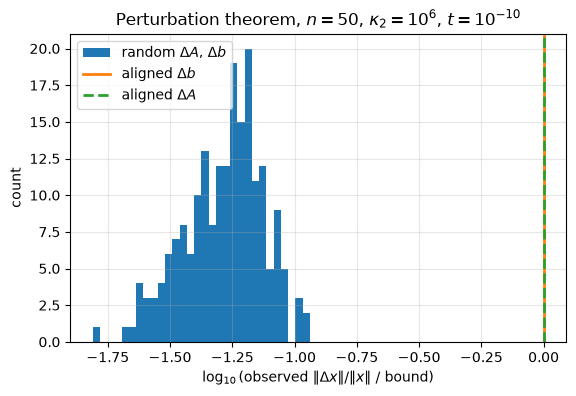

In [6]:
assert 0.99 < ratio_A <= 1 + 1e-4

fig, ax = plt.subplots()
ax.hist(np.log10(ratios_random), bins=30, label="random $\\Delta A$, $\\Delta b$")
ax.axvline(np.log10(ratio_b), color="C1", lw=2, label="aligned $\\Delta b$")
ax.axvline(np.log10(ratio_A), color="C2", lw=2, ls="--", label="aligned $\\Delta A$")
ax.set_xlabel(r"$\log_{10}$(observed $\|\Delta x\|/\|x\|$ / bound)")
ax.set_ylabel("count")
ax.set_title(r"Perturbation theorem, $n = 50$, $\kappa_2 = 10^6$, $t = 10^{-10}$")
ax.legend()
plt.show()

**Interpretation.** Random perturbations of the same size produce errors
roughly ten to twenty times smaller than the bound (see the printed median
and maximum). They are not aligned with the worst directions: a random
$\Delta A$ does not stretch $x$ by its full norm, and a random vector has a
component of relative size only about $1/\sqrt n$ along each left singular
vector, of which only the few belonging to the smallest singular values are
amplified by nearly $1/\sigma_n$. The bound is a worst case, attained for
aligned perturbations. That is the precise sense in which the perturbation
bound, and the estimate $\kappa u$ derived from it, is sharp.

## 4. The distance to singularity

By [Theorem 4.3](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-thm-distance) the perturbation $\Delta A = -\sigma_n u_n v_n^T$,
of relative size $1/\kappa_2(A)$, makes $A$ singular. A random perturbation of
the same norm changes $\sigma_n$ by much less.

In [7]:
Usvd, sv, Vtsvd = np.linalg.svd(A)
dA_sing = -sv[-1] * np.outer(Usvd[:, -1], Vtsvd[-1, :])
E = rng.standard_normal((n, n))
dA_rand = sv[-1] * E / np.linalg.norm(E, 2)
smin_sing = np.linalg.svd(A + dA_sing, compute_uv=False)[-1]
smin_rand = np.linalg.svd(A + dA_rand, compute_uv=False)[-1]
print(f"||dA||_2/||A||_2 = {np.linalg.norm(dA_sing, 2) / sv[0]:.3e}   1/kappa_2 = {sv[-1] / sv[0]:.3e}")
print(f"sigma_min(A + dA), aligned: {smin_sing:.2e}   random: {smin_rand:.2e}   sigma_min(A) = {sv[-1]:.2e}")
# The SVD of A + dA is computed with absolute errors of order n u sigma_1.
assert smin_sing < 10 * n * u * sv[0]

||dA||_2/||A||_2 = 1.000e-06   1/kappa_2 = 1.000e-06
sigma_min(A + dA), aligned: 6.40e-18   random: 9.04e-07   sigma_min(A) = 1.00e-06


The aligned perturbation reduces $\sigma_{\min}$ to rounding level, that is,
it makes $A$ singular to working precision. The random perturbation of the same
norm leaves $\sigma_{\min}$ of the same order as before.

## 5. Forward error, backward error and $\kappa u$ for `numpy.linalg.solve`

Now we solve $Ax = b$ with `numpy.linalg.solve` (LAPACK's LU with partial
pivoting) for condition numbers from $1$ to $10^{15}$. For each computed $y$ we
record:

- the forward error $\|y - x\|_2/\|x\|_2$;
- the Rigal--Gaches backward error $\eta(y) = \|r\|_2/(\|A\|_2\|y\|_2 + \|b\|_2)$
  ([Theorem 4.6](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-thm-rigal-gaches));
- the relative residual $\|r\|_2/\|b\|_2$, which is **not** the backward error.

There is a subtlety. The right-hand side `b = A @ x` is rounded, so $x$ is not
the exact solution of the stored system. We therefore regard the problem as
$Ax = b'$ with $b' = Ax$ *exactly*, so that $x$ is its exact solution, and
evaluate the residual $b' - Ay = A(x - y)$ in exact rational arithmetic. (The
floating-point residual `b - A @ y` has its own rounding error, of size up to
$\gamma_{n+1}(|b|+|A||y|)$, which would swamp a backward error of order $u$.)
Then [(4.11)](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#equation-ch04-eq-linear-accuracy) gives a rigorous bound
$2\kappa\eta/(1-\kappa\eta)$ for the forward error.

In [8]:
def exact_residual_norm(A, x, y):
    """||A (x - y)||_2 evaluated in exact rational arithmetic (then rounded once)."""
    m = A.shape[0]
    d = [xi - yi for xi, yi in zip(fractions_of(x), fractions_of(y))]
    Af = fractions_of(A)
    r = [sum(Af[i * m + j] * d[j] for j in range(m)) for i in range(m)]
    return math.sqrt(float(sum(ri * ri for ri in r)))


n = 30
rows = []
for kexp in range(0, 16, 1):
    kappa = 10.0 ** kexp
    A, _, _ = matrix_with_singular_values(np.logspace(0, -kexp, n))
    x = rng.standard_normal(n)
    b = A @ x
    y = np.linalg.solve(A, b)
    normA = np.linalg.norm(A, 2)
    eta = exact_residual_norm(A, x, y) / (normA * np.linalg.norm(y) + np.linalg.norm(A @ x))
    fwd = np.linalg.norm(y - x) / np.linalg.norm(x)
    r_float = b - A @ y
    rows.append((kappa, fwd, eta, np.linalg.norm(r_float) / np.linalg.norm(b)))
    # LU with partial pivoting: eta <= p(n) * growth * u; the growth factor is small for these
    # matrices, and 10 n u is a generous allowance.
    assert eta < 10 * n * u
    kappa_true = np.linalg.cond(A)
    if kappa_true * eta < 0.5:                 # rigorous bound (1.01 covers rounding in the norms)
        assert fwd <= 1.01 * 2 * kappa_true * eta / (1 - kappa_true * eta)

print(f"{'kappa':>8s} {'forward':>10s} {'eta':>10s} {'||r||/||b||':>12s} {'kappa*u':>10s}")
for kappa, fwd, eta, rr in rows:
    print(f"{kappa:8.0e} {fwd:10.2e} {eta:10.2e} {rr:12.2e} {kappa * u:10.2e}")

   kappa    forward        eta  ||r||/||b||    kappa*u
   1e+00   8.57e-16   4.29e-16     8.64e-16   1.11e-16
   1e+01   1.08e-15   1.46e-16     4.68e-16   1.11e-15
   1e+02   3.78e-15   9.11e-17     2.90e-16   1.11e-14
   1e+03   1.11e-14   6.39e-17     2.47e-16   1.11e-13
   1e+04   1.06e-13   7.37e-17     4.73e-16   1.11e-12
   1e+05   6.63e-13   5.58e-17     4.01e-16   1.11e-11
   1e+06   2.27e-12   4.78e-17     4.41e-16   1.11e-10
   1e+07   4.33e-11   4.32e-17     6.81e-16   1.11e-09
   1e+08   1.05e-09   3.12e-17     2.15e-16   1.11e-08
   1e+09   1.21e-08   3.28e-17     1.32e-16   1.11e-07
   1e+10   7.06e-08   4.33e-17     2.75e-16   1.11e-06
   1e+11   3.24e-07   1.98e-17     4.22e-16   1.11e-05
   1e+12   1.26e-05   3.91e-17     2.51e-16   1.11e-04
   1e+13   5.39e-05   2.75e-17     6.79e-16   1.11e-03
   1e+14   6.38e-04   2.26e-17     3.48e-16   1.11e-02
   1e+15   6.03e-03   3.39e-17     1.35e-16   1.11e-01


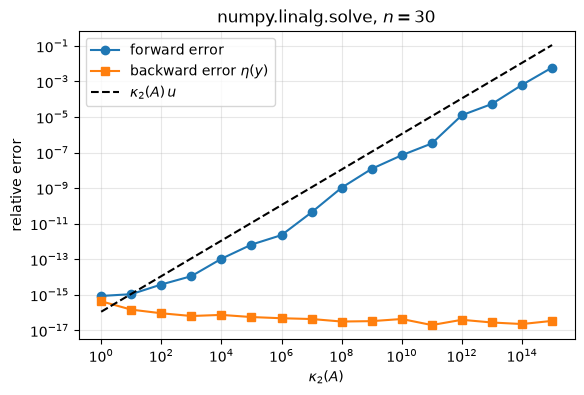

In [9]:
K = np.array([r[0] for r in rows])
fig, ax = plt.subplots()
ax.loglog(K, [r[1] for r in rows], "o-", label="forward error")
ax.loglog(K, np.maximum([r[2] for r in rows], 1e-18), "s-", label=r"backward error $\eta(y)$")
ax.loglog(K, K * u, "k--", label=r"$\kappa_2(A)\,u$")
ax.set_xlabel(r"$\kappa_2(A)$")
ax.set_ylabel("relative error")
ax.set_title(r"numpy.linalg.solve, $n = 30$")
ax.legend()
plt.show()

**Interpretation.** The backward error stays at the level of $u$ for every
$\kappa$: the solver is backward stable on these problems. The forward error
grows in proportion to $\kappa_2(A)$, as the rule "forward error $\lesssim$
condition number $\times$ backward error" predicts. For $\kappa$ near $1$ it
is a few units of $u$ (the constant hidden in "$O(\kappa u)$"); for
$\kappa\ge10^2$ it stays below $\kappa_2(A)u$, by factors of roughly $3$ to $50$ in
this run, because the rounding errors are not aligned with the worst
directions. Compare [Figure 4.4](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-fig-solve) in the notes. For this
right-hand side, $b = Ax$ with a random $x$, the relative residual is also
small, but that is a property of $b$, as the next experiment shows.

### The relative residual is not the backward error

Take instead a random right-hand side $b$. Then $x = A^{-1}b$ is dominated by
the components along the singular vectors with small singular values, so
$\|A\|\|x\|\gg\|b\|$ and the relative residual exceeds $\eta$ by roughly the
factor $\|A\|\|y\|/\|b\|$ ([Exercise 4.5](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-ex-one-sided-backward)).

In [10]:
print(f"{'kappa':>8s} {'eta':>10s} {'||r||/(||A|| ||y||)':>20s} {'||r||/||b||':>12s} {'||A|| ||y||/||b||':>18s}")
for kexp in (0, 4, 8, 12):
    A, _, _ = matrix_with_singular_values(np.logspace(0, -kexp, n))
    b = rng.standard_normal(n)
    y = np.linalg.solve(A, b)
    r = b - A @ y
    normA, ny, nb, nr = np.linalg.norm(A, 2), np.linalg.norm(y), np.linalg.norm(b), np.linalg.norm(r)
    eta = nr / (normA * ny + nb)
    print(f"{10.0**kexp:8.0e} {eta:10.2e} {nr / (normA * ny):20.2e} {nr / nb:12.2e} {normA * ny / nb:18.2e}")
    # eta <= eta_A = ||r|| / (||A|| ||y||) always; since ||b|| <= ||A|| ||y|| + ||r||, the reciprocals
    # 1/eta = 1/eta_A + 1/eta_b also give eta_A <= (2 + eta_A) eta (10 n u covers rounding in the norms).
    eta_A = nr / (normA * ny)
    assert eta <= eta_A <= (2 + eta_A) * eta * (1 + 10 * n * u)
    assert eta < 10 * n * u                                  # backward stable solver

   kappa        eta  ||r||/(||A|| ||y||)  ||r||/||b||  ||A|| ||y||/||b||
   1e+00   4.49e-16             8.98e-16     8.98e-16           1.00e+00
   1e+04   5.29e-17             5.29e-17     9.68e-14           1.83e+03
   1e+08   3.48e-17             3.48e-17     3.25e-10           9.34e+06
   1e+12   3.08e-17             3.08e-17     3.17e-06           1.03e+11


The Rigal--Gaches backward error and the backward error with only $A$
perturbed are both of order $u$ (their reciprocals add, so they differ by at
most a factor $2$). The relative residual grows with $\kappa$ and is
nevertheless no evidence of instability: it is the backward error for
perturbations of $b$ alone, and a backward stable solver does not promise to
make that small. (Here the floating-point residual is used; its rounding
error is of the same order as the residuals themselves when $\kappa$ is
small, but this does not affect the conclusion.)

## 6. Componentwise conditioning: Skeel's condition number

We scale the rows of a random matrix $B$ by factors from $1$ to $10^{-12}$:
$A = DB$. The normwise condition number $\kappa_\infty(A)$ is huge, but
Skeel's condition number $\operatorname{cond}(A) = \||A^{-1}||A|\|_\infty$ does
not see the row scaling ([Proposition 4.2](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-prop-skeel)).

In [11]:
def skeel(A, x=None):
    """cond(A) = || |A^-1| |A| ||_inf, or cond(A, x) if x is given."""
    M = np.abs(np.linalg.inv(A)) @ np.abs(A)
    if x is None:
        return np.linalg.norm(M, np.inf)
    return np.linalg.norm(M @ np.abs(x), np.inf) / np.linalg.norm(x, np.inf)


n = 50
B = rng.standard_normal((n, n))
D = np.logspace(0, -12, n)
A = D[:, None] * B
x = rng.standard_normal(n)
b = A @ x
y = np.linalg.solve(A, b)

kinf_A, kinf_B = np.linalg.cond(A, np.inf), np.linalg.cond(B, np.inf)
condA, condAx, condB = skeel(A), skeel(A, x), skeel(B)
fwd = np.linalg.norm(y - x, np.inf) / np.linalg.norm(x, np.inf)
print(f"kappa_inf(B) = {kinf_B:.2e}   kappa_inf(A) = {kinf_A:.2e}")
print(f"cond(B) = {condB:.2e}   cond(A) = {condA:.2e}   cond(A, x) = {condAx:.2e}")
print(f"forward error (inf-norm) = {fwd:.2e};  cond(A,x) u = {condAx * u:.2e};  kappa_inf(A) u = {kinf_A * u:.2e}")
# cond(DA) = cond(A) exactly in exact arithmetic; the computed inverses differ by rounding.
assert abs(condA / condB - 1) < 1e-6

kappa_inf(B) = 4.19e+03   kappa_inf(A) = 1.29e+14
cond(B) = 3.22e+03   cond(A) = 3.22e+03   cond(A, x) = 1.28e+03
forward error (inf-norm) = 5.75e-14;  cond(A,x) u = 1.43e-13;  kappa_inf(A) u = 1.43e-02


The forward error is of the order of $\operatorname{cond}(A,x)u$ or smaller,
and many orders of magnitude below $\kappa_\infty(A)u$. To see why, compute the
componentwise backward error of Oettli and Prager,
$\omega(y) = \max_i|r_i|/(|A||y|+|b|)_i$ ([Theorem 4.7](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-thm-oettli-prager)),
again with the exact residual $A(x-y)$. If $\omega$ is of order $u$, then
[Theorem 4.4](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-thm-componentwise) bounds the forward error by
$2\omega\operatorname{cond}(A,x)/(1-\omega\operatorname{cond}(A))$.

In [12]:
def exact_omega(A, x, y):
    """Oettli-Prager backward error of y for the system A z = A x (exact right-hand side)."""
    m = A.shape[0]
    d = [xi - yi for xi, yi in zip(fractions_of(x), fractions_of(y))]
    Af, xf, yf = fractions_of(A), fractions_of(x), fractions_of(y)
    omega = Fraction(0)
    for i in range(m):
        row = Af[i * m:(i + 1) * m]
        ri = abs(sum(a * dj for a, dj in zip(row, d)))
        denom = sum(abs(a) * abs(yj) for a, yj in zip(row, yf)) + abs(sum(a * xj for a, xj in zip(row, xf)))
        omega = max(omega, ri / denom)
    return float(omega)


omega = exact_omega(A, x, y)
bound_comp = 2 * omega * condAx / (1 - omega * condA)
print(f"omega(y) = {omega:.2e}  (u = {u:.2e})")
print(f"componentwise bound on the forward error: {bound_comp:.2e}; observed {fwd:.2e}")
assert omega * condA < 0.5
assert fwd <= 1.01 * bound_comp            # 1.01 allows for rounding in the computed cond(A, x)

omega(y) = 1.80e-15  (u = 1.11e-16)
componentwise bound on the forward error: 4.61e-12; observed 5.75e-14


The componentwise backward error is a small multiple of $u$ here: on this
example Gaussian elimination with partial pivoting behaves as if it perturbed
each entry of $A$ by a relative amount of order $u$, and such perturbations
are harmless because row scaling does not affect them. This is an
observation about this matrix; partial pivoting does not guarantee a small
$\omega$ in general, but one step of iterative refinement usually does
(Skeel, 1980) ([Chapter 6](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06)).

Finally we compare random componentwise and random normwise perturbations of
the same relative size $t = 10^{-10}$.

In [13]:
t = 1e-10
x0 = np.linalg.solve(A, b)
err_comp, err_norm = [], []
for _ in range(50):
    dA_c = t * np.abs(A) * rng.uniform(-1, 1, A.shape)          # |dA| <= t |A|
    E = rng.standard_normal(A.shape)
    dA_n = t * np.linalg.norm(A, np.inf) * E / np.linalg.norm(E, np.inf)   # ||dA|| = t ||A||
    err_comp.append(np.linalg.norm(np.linalg.solve(A + dA_c, b) - x0, np.inf) / np.linalg.norm(x0, np.inf))
    err_norm.append(np.linalg.norm(np.linalg.solve(A + dA_n, b) - x0, np.inf) / np.linalg.norm(x0, np.inf))
print(f"componentwise perturbations: max relative change {max(err_comp):.2e} "
      f"(bound t cond(A,x)/(1 - t cond(A)) = {t * condAx / (1 - t * condA):.2e})")
print(f"normwise perturbations:      max relative change {max(err_norm):.2e} "
      f"(t kappa_inf(A) = {t * kinf_A:.2e})")
# The computed solutions themselves carry errors of order cond(A, x) u ~ 1e-13, negligible here.
assert max(err_comp) <= 1.01 * t * condAx / (1 - t * condA)

componentwise perturbations: max relative change 5.88e-09 (bound t cond(A,x)/(1 - t cond(A)) = 1.28e-07)
normwise perturbations:      max relative change 8.57e+01 (t kappa_inf(A) = 1.29e+04)


Normwise perturbations of relative size $10^{-10}$ destroy the equations with
tiny coefficients and change the solution completely, while componentwise
perturbations of the same size change it by less than
$t\operatorname{cond}(A,x)$, as [Theorem 4.4](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-thm-componentwise) guarantees.
The perturbation model must match the errors the data actually have.

## 7. Stable and unstable algorithms

### Inner products

By [Theorem 4.8](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-thm-inner-product), recursive summation computes
$\widehat{x^Ty}$ with $|\widehat{x^Ty} - x^Ty|\le\gamma_n|x|^T|y|$. We check
this bound exactly with rational arithmetic, for vectors that are nearly
orthogonal, so that the componentwise condition number $|x|^T|y|/|x^Ty|$ is
large.

In [14]:
def dot_recursive(x, y):
    s = 0.0
    for xi, yi in zip(x, y):
        s += xi * yi
    return s


n = 1000
x = rng.standard_normal(n)
y = rng.standard_normal(n)
y -= (x @ y) / (x @ x) * x                    # make y nearly orthogonal to x
y += 1e-8 * rng.standard_normal(n)
s_hat = dot_recursive(x, y)
s_exact = sum(a * b for a, b in zip(fractions_of(x), fractions_of(y)))
abs_err = abs(Fraction(s_hat) - s_exact)
scale = float(np.abs(x) @ np.abs(y))
cond_dot = scale / abs(float(s_exact))
print(f"x^T y = {float(s_exact):.3e}, condition number |x|^T|y|/|x^T y| = {cond_dot:.2e}")
print(f"absolute error = {float(abs_err):.2e}, bound gamma_n |x|^T|y| = {gamma(n) * scale:.2e}")
print(f"relative error = {float(abs_err) / abs(float(s_exact)):.2e}, bound gamma_n * condition = {gamma(n) * cond_dot:.2e}")
assert float(abs_err) <= gamma(n) * scale

x^T y = -3.199e-07, condition number |x|^T|y|/|x^T y| = 2.00e+09
absolute error = 2.87e-14, bound gamma_n |x|^T|y| = 7.09e-11
relative error = 8.97e-08, bound gamma_n * condition = 2.21e-04


The relative error is large because the problem is ill-conditioned, but the
algorithm is backward stable: the error is within the bound
$\gamma_n|x|^T|y|$, which is the error caused by relative perturbations of
size $\gamma_n$ in the entries of $x$.

### Outer products are not backward stable

Every entry of the computed outer product $\operatorname{fl}(xy^T)$ is correct to relative
error $u$, but the computed matrix is generally not of rank one, so it is not
the exact outer product of any perturbed vectors. We verify this by computing
a $2\times2$ minor exactly.

In [15]:
xo = np.array([0.1, 0.7])
yo = np.array([0.3, 0.9])
P = np.outer(xo, yo)
Pf = [[Fraction(float(v)) for v in row] for row in P]
minor = Pf[0][0] * Pf[1][1] - Pf[0][1] * Pf[1][0]
rel_entry_err = max(abs(Fraction(float(P[i, j])) - Fraction(float(xo[i])) * Fraction(float(yo[j])))
                    / abs(Fraction(float(xo[i])) * Fraction(float(yo[j]))) for i in range(2) for j in range(2))
print(f"max relative error of an entry: {float(rel_entry_err):.2e} (<= u = {u:.2e})")
print(f"exact determinant of the computed 2x2 outer product: {float(minor):.3e}")
assert rel_entry_err <= u
assert minor != 0          # not rank one, hence not (x + dx)(y + dy)^T for any dx, dy

max relative error of an entry: 6.34e-17 (<= u = 1.11e-16)
exact determinant of the computed 2x2 outer product: -2.082e-18


### $e^{-x}$ from its Taylor series

[Example 4.5](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-exa-exp) claims that summing $\sum_k(-x)^k/k!$ is unstable
for large $x$ although the problem has condition number only $|x|$, and that
$1/\sum_kx^k/k!$ is stable.

In [16]:
def exp_taylor(x):
    """Sum the Taylor series of e^x until the partial sums stop changing."""
    s, term, k = 1.0, 1.0, 0
    while True:
        k += 1
        term = term * x / k
        s_new = s + term
        if s_new == s:
            return s
        s = s_new


print(f"{'x':>4s} {'series for e^-x':>16s} {'rel. error':>11s} {'1/series e^x':>13s} {'rel. error':>11s} {'u e^(2x)':>10s}")
for xv in (1, 5, 10, 15, 20, 25, 30):
    ref = math.exp(-xv)
    naive, stable = exp_taylor(-xv), 1 / exp_taylor(xv)
    print(f"{xv:4d} {naive:16.6e} {abs(naive - ref) / ref:11.2e} {stable:13.6e} "
          f"{abs(stable - ref) / ref:11.2e} {u * math.exp(2 * xv):10.2e}")
    # the stable algorithm: a sum of positive terms (error <= ~ k u) and a reciprocal; math.exp is
    # accurate to about u, so 100 u is a generous tolerance for this well-conditioned problem.
    assert abs(stable - ref) / ref < 100 * u

   x  series for e^-x  rel. error  1/series e^x  rel. error   u e^(2x)
   1     3.678794e-01    3.02e-16  3.678794e-01    1.51e-16   8.20e-16
   5     6.737947e-03    2.13e-13  6.737947e-03    3.86e-16   2.45e-12
  10     4.539993e-05    3.07e-09  4.539993e-05    1.49e-16   5.39e-08
  15     3.059094e-07    2.32e-05  3.059023e-07    3.46e-16   1.19e-03
  20     5.621884e-09    1.73e+00  2.061154e-09    2.01e-16   2.61e+01
  25    -7.129780e-07    5.13e+04  1.388794e-11    1.16e-16   5.76e+05
  30    -3.066812e-05    3.28e+08  9.357623e-14    4.05e-16   1.27e+10


The error of the alternating series grows like $u\,e^{2x}$, $u$ times the
condition number of the intermediate summation; at $x = 25$ the computed
"$e^{-25}$" is negative. The reciprocal of the positive series is accurate to
a few units of $u$ for every $x$. Both algorithms sum the same kind of series;
only the conditioning of the intermediate problem differs.

### $1 - \cos x$

In [17]:
print(f"{'x':>8s} {'1 - cos x':>14s} {'2 sin^2(x/2)':>14s} {'rel. difference':>16s}")
for xv in 10.0 ** -np.arange(1, 11):
    naive = 1 - np.cos(xv)
    stable = 2 * np.sin(xv / 2) ** 2
    print(f"{xv:8.0e} {naive:14.6e} {stable:14.6e} {abs(naive - stable) / stable:16.2e}")
assert 1 - np.cos(1e-8) == 0.0          # cos(1e-8) = 1 - 5e-17 rounds to 1

       x      1 - cos x   2 sin^2(x/2)  rel. difference
   1e-01   4.995835e-03   4.995835e-03         1.09e-14
   1e-02   4.999958e-05   4.999958e-05         2.89e-13
   1e-03   5.000000e-07   5.000000e-07         1.57e-11
   1e-04   5.000000e-09   5.000000e-09         5.24e-09
   1e-05   5.000000e-11   5.000000e-11         8.27e-08
   1e-06   5.000445e-13   5.000000e-13         8.89e-05
   1e-07   4.996004e-15   5.000000e-15         7.99e-04
   1e-08   0.000000e+00   5.000000e-17         1.00e+00
   1e-09   0.000000e+00   5.000000e-19         1.00e+00
   1e-10   0.000000e+00   5.000000e-21         1.00e+00


### Eigenvalues through the characteristic polynomial

The eigenvalues of $\operatorname{diag}(1,\dots,20)$ are perfectly
conditioned, but its characteristic polynomial is Wilkinson's polynomial
([Remark 4.2](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-rem-charpoly)). Computing its coefficients in floating point
(they exceed $2^{53}$, so they are rounded) and then its roots loses many
digits.

In [18]:
D20 = np.diag(np.arange(1.0, 21.0))
eig_direct = np.sort(np.linalg.eigvalsh(D20))
roots_charpoly = np.sort_complex(np.roots(np.poly(D20)))
print(f"max error, eigvalsh:                 {np.max(np.abs(eig_direct - np.arange(1, 21))):.1e}")
print(f"max error, roots of char. polynomial: {np.max(np.abs(roots_charpoly - np.arange(1, 21))):.1e}")
print("largest coefficient:", f"{np.max(np.abs(np.poly(D20))):.3e}", "> 2**53 =", f"{2.0**53:.3e}")

max error, eigvalsh:                 0.0e+00
max error, roots of char. polynomial: 9.3e-02
largest coefficient: 1.380e+19 > 2**53 = 9.007e+15


The direct eigenvalue computation is exact here; the detour through the
characteristic polynomial loses most of the sixteen digits, although each of
its steps is carried out accurately.

## 8. The Hilbert matrix: data error versus solver error

We repeat [Example 4.6](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-exa-hilbert). The stored matrix is
$\hat H = \operatorname{fl}(H_n)$ and the stored right-hand side is
$\hat b = \operatorname{fl}(H_ne)$, the correctly rounded exact row sums. We
compute three solutions:

- $e$, the exact solution of the exact problem;
- $\hat x$, the exact solution of the stored problem, by Gaussian elimination
  in rational arithmetic;
- $y$, the solution returned by `numpy.linalg.solve`.

The difference $\hat x - e$ is caused by rounding the data alone; the
difference $y - \hat x$ is caused by the solver. We also compute
$\kappa_2(H_n)$ from the exact integer inverse, `scipy.linalg.invhilbert(n,
exact=True)`, because the condition number of the rounded matrix is itself
inaccurate for large $n$.

In [19]:
def solve_exact(Af, bf, n):
    """Gaussian elimination in rational arithmetic (Af: list of n*n Fractions)."""
    M = [Af[i * n:(i + 1) * n] + [bf[i]] for i in range(n)]
    for k in range(n):
        p = next(i for i in range(k, n) if M[i][k] != 0)
        M[k], M[p] = M[p], M[k]
        for i in range(k + 1, n):
            f = M[i][k] / M[k][k]
            if f:
                for j in range(k, n + 1):
                    M[i][j] -= f * M[k][j]
    xs = [Fraction(0)] * n
    for i in reversed(range(n)):
        xs[i] = (M[i][n] - sum(M[i][j] * xs[j] for j in range(i + 1, n))) / M[i][i]
    return xs


hilbert_rows = []
for n in range(4, 14):
    H = sla.hilbert(n)
    b_exact = [sum(Fraction(1, i + j + 1) for j in range(n)) for i in range(n)]
    b = np.array([float(v) for v in b_exact])            # correctly rounded
    x_hat = solve_exact(fractions_of(H), fractions_of(b), n)
    y = np.linalg.solve(H, b)
    Hinv = np.array(sla.invhilbert(n, exact=True), dtype=float)
    kappa2 = np.linalg.eigvalsh(H)[-1] * np.linalg.eigvalsh(Hinv)[-1]
    data_err = float(max(abs(v - 1) for v in x_hat))                           # ||x_hat - e||_inf
    solver_err = float(max(abs(Fraction(float(yi)) - v) for yi, v in zip(y, x_hat)) / max(abs(v) for v in x_hat))
    total_err = np.max(np.abs(y - 1))
    r = [bi - sum(a * yj for a, yj in zip(fractions_of(H[i]), fractions_of(y)))
         for i, bi in enumerate(fractions_of(b))]
    eta = math.sqrt(float(sum(v * v for v in r))) / (np.linalg.norm(H, 2) * np.linalg.norm(y) + np.linalg.norm(b))
    hilbert_rows.append((n, kappa2, data_err, solver_err, total_err, eta))
    assert eta < 10 * n * u                 # backward stable solver (with the exact residual)

print(f"{'n':>3s} {'kappa_2':>10s} {'kappa_2 u':>10s} {'data err':>10s} {'solver err':>11s} {'total err':>10s} {'eta':>9s}")
for n, k2, de, se, te, eta in hilbert_rows:
    print(f"{n:3d} {k2:10.2e} {k2 * u:10.2e} {de:10.2e} {se:11.2e} {te:10.2e} {eta:9.1e}")

  n    kappa_2  kappa_2 u   data err  solver err  total err       eta
  4   1.55e+04   1.72e-12   3.23e-13    8.45e-14   2.39e-13   8.9e-18
  5   4.77e+05   5.29e-11   1.78e-12    9.99e-13   2.78e-12   5.3e-17
  6   1.50e+07   1.66e-09   1.68e-10    1.97e-10   2.95e-11   6.9e-17
  7   4.75e+08   5.28e-08   6.85e-09    8.66e-09   1.81e-09   1.7e-17
  8   1.53e+10   1.69e-06   5.65e-07    2.19e-07   3.46e-07   4.4e-17
  9   4.93e+11   5.48e-05   1.86e-06    4.09e-07   2.27e-06   5.6e-17
 10   1.60e+13   1.78e-03   4.73e-04    1.05e-04   5.78e-04   4.4e-17
 11   5.23e+14   5.81e-02   4.04e-03    1.45e-03   5.50e-03   1.5e-17
 12   1.71e+16   1.90e+00   3.07e-01    3.93e-01   2.07e-01   2.1e-17
 13   5.63e+17   6.25e+01   1.56e+01    7.47e-01   3.53e+00   4.2e-17


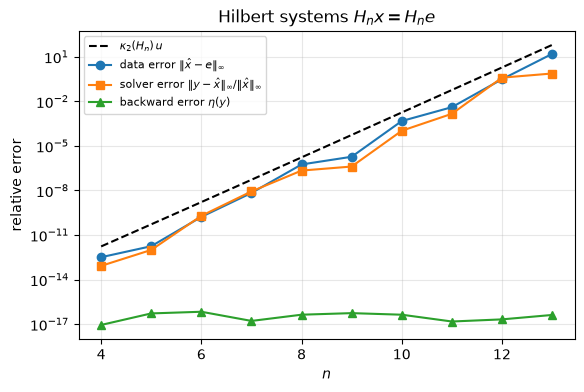

In [20]:
ns = [r[0] for r in hilbert_rows]
fig, ax = plt.subplots()
ax.semilogy(ns, [r[1] * u for r in hilbert_rows], "k--", label=r"$\kappa_2(H_n)\,u$")
ax.semilogy(ns, [r[2] for r in hilbert_rows], "o-", label=r"data error $\|\hat x - e\|_\infty$")
ax.semilogy(ns, [r[3] for r in hilbert_rows], "s-", label=r"solver error $\|y - \hat x\|_\infty/\|\hat x\|_\infty$")
ax.semilogy(ns, [r[5] for r in hilbert_rows], "^-", label=r"backward error $\eta(y)$")
ax.set_xlabel("$n$")
ax.set_ylabel("relative error")
ax.set_title("Hilbert systems $H_n x = H_n e$")
ax.legend(fontsize=8)
plt.show()

**Interpretation.** Rounding the data costs as many digits as the solver
does: the data error and the solver error are of the same order, both a
modest fraction of $\kappa_2(H_n)u$, and the backward error of the solver
stays at the level of $u$. For $n = 10$ about three digits survive, and for
$n\ge12$ none: $\kappa_2(H_n)u > 1$, so the stored matrix is numerically
singular ([Theorem 4.3](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-thm-distance)). No algorithm working with the
rounded data can do better in general, because the rounded data do not
determine the solution more precisely. This is the correct form of the
"digits lost" rule of thumb.

Finally, we compare the data error with the componentwise bound of
[Theorem 4.4](https://aalsammani.github.io/numerical-linear-algebra/ch04-conditioning-stability/notes.html#ch04-thm-componentwise), $2u\operatorname{cond}(H_n,e)/(1-u\operatorname{cond}(H_n))$,
evaluated exactly with the integer inverse.

In [21]:
for n, k2, de, *_ in hilbert_rows:
    Hinv = sla.invhilbert(n, exact=True)
    Hf = [[Fraction(1, i + j + 1) for j in range(n)] for i in range(n)]
    He = [sum(row) for row in Hf]
    cond_x = max(sum(abs(int(Hinv[i][j])) * He[j] for j in range(n)) for i in range(n))
    cond_H = max(sum(abs(int(Hinv[i][k])) * Hf[k][j] for k in range(n) for j in range(n)) for i in range(n))
    if u * cond_H < 1:
        bound = 2 * u * float(cond_x) / (1 - u * float(cond_H))
        print(f"n = {n:2d}: data error {de:.2e} <= bound {bound:.2e}")
        assert de <= bound
    else:
        print(f"n = {n:2d}: u cond(H_n) = {u * float(cond_H):.1f} >= 1, the bound does not apply")

n =  4: data error 3.23e-13 <= bound 2.96e-12
n =  5: data error 1.78e-12 <= bound 8.77e-11
n =  6: data error 1.68e-10 <= bound 2.48e-09
n =  7: data error 6.85e-09 <= bound 7.89e-08
n =  8: data error 5.65e-07 <= bound 2.57e-06
n =  9: data error 1.86e-06 <= bound 7.96e-05
n = 10: data error 4.73e-04 <= bound 2.46e-03
n = 11: data error 4.04e-03 <= bound 8.65e-02
n = 12: u cond(H_n) = 1.3 >= 1, the bound does not apply
n = 13: u cond(H_n) = 42.0 >= 1, the bound does not apply


## Common mistakes

- Using the relative residual $\|b - Ay\|/\|b\|$ as "the backward error." It
  is the backward error for perturbations of $b$ alone and can be larger than
  the Rigal--Gaches backward error by a factor up to about $1+\kappa(A)$.
- Reading $\kappa u$ as a prediction of the error. It is a worst-case bound
  for backward stable algorithms; actual errors are often much smaller, and
  for structured perturbations Skeel's condition number may be the relevant
  quantity.
- Computing the backward error from a floating-point residual and trusting
  values below about $nu$: the residual has rounding errors of that size.
- Measuring the error against `x_true` after forming `b = A @ x_true` in
  floating point: $x_{\rm true}$ is then not the exact solution of the stored
  system, and for ill-conditioned $A$ the difference is of order $\kappa u$.
- Trusting `np.linalg.cond(A)` when $\kappa(A)u$ is not small: the computed
  condition number of a numerically singular matrix is not accurate.
- Blaming the subtraction for cancellation errors. The subtraction is exact
  or nearly so; the error was already in its operands.

## Your turn

1. Repeat Section 3 with the 1-norm instead of the 2-norm. Which aligned
   perturbations attain the bound now? (Use a column of $A^{-1}$ with maximal
   1-norm.)
2. In Section 5, replace `numpy.linalg.solve` by Gaussian elimination
   *without* pivoting (write it yourself) and use the matrix
   $\begin{bmatrix}10^{-20}&1\\1&1\end{bmatrix}$. Compute $\kappa_2(A)$ and
   $\eta(y)$. Is the problem ill-conditioned? Is the algorithm backward stable?
3. For the row-scaled matrix of Section 6, scale the *columns* instead of the
   rows. Does Skeel's condition number still explain the forward error?
4. Estimate the condition number of the problem $x\mapsto\tan x$ near
   $x = \pi/2$ numerically and compare with $|x/(\sin x\cos x)|$.

## Key takeaways

- The condition number belongs to the problem, the backward error to the
  algorithm, and forward error $\lesssim$ condition number $\times$ backward
  error.
- The perturbation bound for $Ax = b$ is attained only by aligned
  perturbations; random perturbations typically do much less damage.
- For a computed solution, the Rigal--Gaches backward error
  $\|r\|/(\|A\|\|y\|+\|b\|)$ is the right normwise measure; the relative
  residual is not.
- Skeel's condition number is invariant under row scaling and explains
  accurate solutions of badly scaled systems.
- Unstable algorithms pass through ill-conditioned intermediate problems;
  stable reformulations avoid them.
- For the Hilbert matrix, the digits are lost when the data are rounded.

## Further reading

Trefethen and Bau (1997), Lectures 12, 14 and 15 (with
$\epsilon_{\text{machine}}$ for our $u$); Higham (2002), Chapters 1,
3 and 7; Demmel (1997), Sections 1.3, 1.4 and 2.2;
Golub and Van Loan (2013), Sections 2.6, 2.7 and 3.5.